# Generative AI for Computer Vision — HW1
**CSCE 689 — Fall 2026 (AI4CV)**

## Part 2: Finetuning pretrained CNN on the downstream task
In this part, you will finetune a pretrained CNN model to another task. Finetuning is powerful with the following strengths:
1. **Faster training** : It starts with pre-trained weights which allow the model to converge faster than training from scratch.
2. **Domain Adaptation** : Fine-tuning is effective for adapting a model trained on one domain to another.
3. **Transfer Learning**...and more

In this part, you will finetune on BDD weather classifcation dataset, more details here: https://www.kaggle.com/datasets/marquis03/bdd100k-weather-classification

### Tasks
1. Follow the steps and complete your finetuning procedure
2. Compare the training/val loss/accuracy curve between training from scratch and finetuning
3. Plot the confusion matrix for two cases

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from torch import Tensor
from typing import Type

# Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os
import pdb

import kagglehub

/tmp/ai4cv_hw1_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### [0 points] Step 1: Download the BDD100K weather classification dataset from Kaggle
Please DO NOT modify this cell.

In [2]:
# Download BDD weather classification dataset
base_dir = kagglehub.dataset_download("marquis03/bdd100k-weather-classification")
print("Path to dataset files:", base_dir)
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'val')

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Path to dataset files: /tmp/ai4cv_kagglehub/datasets/marquis03/bdd100k-weather-classification/versions/1


### [5 points] Step 2: Create the data loader, and split it to train/val

Basically this step is the same as you did in Part 1.
Remember to change the ```num_classes``` to 7, and we will only train for 10 epochs.

1. The original folder structure is: \
   ├── train \
│   ├── labels (such as clear, foggy...) \
│   │   ├── *****.jpg \
│   │   ├── *****.jpg \
│   │   ├── ... \
   It is highly recommended to use ```dataset.ImageFolder``` to load the data!
2. To check how to transform your data, check here: https://pytorch.org/vision/main/transforms.html
3. Later when you train the model, you might need to tune hyperparameters. For example, you may not want the fixed learning rate.


In [3]:
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split
from PIL import Image
from pathlib import Path
import random
import time
import json
import copy

seed = 42
img_size = 64
batch_size = 128
num_epochs = 10
num_classes = 7
learning_rate = 3e-4
num_workers = min(8, os.cpu_count() or 1)
artifact_dir = Path('artifacts/part2')
artifact_dir.mkdir(parents=True, exist_ok=True)

def set_seed(value=seed):
    random.seed(value)
    np.random.seed(value)
    torch.manual_seed(value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(value)

set_seed()
torch.set_num_threads(min(8, os.cpu_count() or 1))
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True

normalize = transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
train_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomCrop(img_size, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(8),
    transforms.ToTensor(), normalize,
])
val_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)), transforms.ToTensor(), normalize,
])

class CachedImageFolder(datasets.ImageFolder):
    def __init__(self, root, transform, cache_name):
        super().__init__(root, transform=transform)
        cache_root = Path(os.environ.get('AI4CV_CACHE_DIR', '/tmp/ai4cv_image_cache'))
        cache_root.mkdir(parents=True, exist_ok=True)
        cache_path = cache_root / f'{cache_name}_{len(self.samples)}_{img_size}.npy'
        shape = (len(self.samples), img_size, img_size, 3)
        if not cache_path.exists():
            from concurrent.futures import ThreadPoolExecutor
            temporary = cache_path.with_suffix('.building.npy')
            pixels = np.lib.format.open_memmap(temporary, mode='w+', dtype=np.uint8, shape=shape)
            resize = transforms.Resize((img_size, img_size))
            def read_image(sample):
                with Image.open(sample[0]) as image:
                    return np.asarray(resize(image.convert('RGB')))
            with ThreadPoolExecutor(max_workers=num_workers) as pool:
                for i, image in enumerate(pool.map(read_image, self.samples)):
                    pixels[i] = image
                    if (i + 1) % 10000 == 0:
                        print(f'{cache_name}: cached {i + 1}/{len(self.samples)} images', flush=True)
            pixels.flush()
            del pixels
            temporary.replace(cache_path)
        self.pixels = np.load(cache_path, mmap_mode='r')
        if self.pixels.shape != shape:
            raise ValueError('Image cache shape does not match this dataset')

    def __getitem__(self, index):
        image = Image.fromarray(self.pixels[index])
        return self.transform(image), self.targets[index]

train_dataset = CachedImageFolder(train_dir, train_transforms, 'bdd_train')
val_dataset = CachedImageFolder(train_dir, val_transforms, 'bdd_train')
test_dataset = CachedImageFolder(test_dir, val_transforms, 'bdd_test')
assert len(train_dataset.classes) == num_classes
assert train_dataset.class_to_idx == test_dataset.class_to_idx
train_indices, val_indices = train_test_split(
    np.arange(len(train_dataset)), test_size=0.2, random_state=seed,
    stratify=train_dataset.targets,
)
train_set = Subset(train_dataset, train_indices)
val_set = Subset(val_dataset, val_indices)

def make_loaders():
    kwargs = dict(batch_size=batch_size, num_workers=num_workers,
                  pin_memory=device.type == 'cuda', persistent_workers=num_workers > 0)
    generator = torch.Generator().manual_seed(seed)
    return (DataLoader(train_set, shuffle=True, generator=generator, **kwargs),
            DataLoader(val_set, shuffle=False, **kwargs),
            DataLoader(test_dataset, shuffle=False, **kwargs))

train_loader, val_loader, test_loader = make_loaders()
print(f'Device: {device}; classes: {train_dataset.classes}')
print(f'Train/validation/test sizes: {len(train_set)}/{len(val_set)}/{len(test_dataset)}')
print('Training class counts:', np.bincount(np.array(train_dataset.targets)[train_indices]))

Device: cuda; classes: ['clear', 'foggy', 'overcast', 'partly cloudy', 'rainy', 'snowy', 'unknown']
Train/validation/test sizes: 55890/13973/10000
Training class counts: [29875   104  7016  3905  4056  4439  6495]


### [5 points] Step 3: Copy your CNN model and training function in Part 1 after this cell

In [4]:
### Define the custom CNN model
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        residual = self.shortcut(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        return self.relu(x + residual)


class yourCNN(nn.Module):
    def __init__(self, num_classes=200):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.layer1 = self._make_layer(64, 64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(64, 128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(256, 512, num_blocks=2, stride=2)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes),
        )

    @staticmethod
    def _make_layer(in_channels, out_channels, num_blocks, stride):
        blocks = [ResidualBlock(in_channels, out_channels, stride)]
        for _ in range(1, num_blocks):
            blocks.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*blocks)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x)
        return self.classifier(x)

def run_epoch(model, loader, criterion, optimizer=None, scaler=None, frozen=False):
    training = optimizer is not None
    model.train(training)
    if training and frozen:
        model.eval()
        model.classifier.train()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for inputs, labels in loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            if training:
                optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, enabled=device.type == 'cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            total_loss += loss.item() * labels.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

def train_model(model, name, frozen=False):
    set_seed()
    train_loader, val_loader, _ = make_loaders()
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW((p for p in model.parameters() if p.requires_grad),
                            lr=learning_rate, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=2)
    scaler = torch.amp.GradScaler(device.type, enabled=device.type == 'cuda')
    history = {key: [] for key in ('train_loss', 'val_loss', 'train_accuracy',
                                   'val_accuracy', 'epoch_seconds')}
    best_accuracy = -1.0
    best_path = artifact_dir / f'{name}_best_weights.pth'
    log_path = artifact_dir / f'{name}_epochs.log'
    with log_path.open('w') as log:
        for epoch in range(num_epochs):
            start_message = f'{name}: epoch {epoch + 1}/{num_epochs} started'
            print(start_message, flush=True)
            log.write(start_message + '\n'); log.flush()
            started = time.perf_counter()
            train_loss, train_accuracy = run_epoch(model, train_loader, criterion, optimizer, scaler, frozen)
            val_loss, val_accuracy = run_epoch(model, val_loader, criterion)
            elapsed = time.perf_counter() - started
            for key, value in zip(history, (train_loss, val_loss, train_accuracy, val_accuracy, elapsed)):
                history[key].append(value)
            scheduler.step(val_loss)
            if val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                torch.save({'epoch': epoch + 1, 'model_state_dict': model.state_dict(),
                            'val_accuracy': val_accuracy, 'classes': train_dataset.classes}, best_path)
            message = (f'{name} Epoch [{epoch + 1}/{num_epochs}] Train Loss: {train_loss:.4f}, '
                       f'Train Accuracy: {train_accuracy:.4f}, Val Loss: {val_loss:.4f}, '
                       f'Val Accuracy: {val_accuracy:.4f}, Seconds: {elapsed:.1f}, '
                       f'LR: {optimizer.param_groups[0]["lr"]:.6g}')
            print(message, flush=True)
            log.write(message + '\n'); log.flush()
            torch.save({'epoch': epoch + 1, 'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'scheduler_state_dict': scheduler.state_dict(),
                        'scaler_state_dict': scaler.state_dict(), 'history': history},
                       artifact_dir / f'{name}_checkpoint.pth')
            (artifact_dir / f'{name}_history.json').write_text(json.dumps(history, indent=2))
    best = torch.load(best_path, map_location=device, weights_only=True)
    model.load_state_dict(best['model_state_dict'])
    print(f'{name}: restored best validation epoch {best["epoch"]}', flush=True)
    torch.save(model.state_dict(), artifact_dir / f'{name}_weights.pth')
    return model, history

### [15 points] Step 4: Compare the difference of finetuning from pretrained model and training from scratch
1. You will need to finetune two models. The first is the model trained from scratch with the BDD dataset, and another is finetuning from pretrained model.
2. For training from scratch, it is almost the same procedure as in Part 1, but the dataset changes.
3. For finetuning, the procedure is:
   * Initialize the model and load the pretrained model using ```torch.load()```, remember that we saved the trained model in Part 1!
   * The output of original CNN is 200 classes, you might need to reinitialize the model to output 7 classes by replacing the last fc layer
   * More details : https://pytorch.org/tutorials/beginner/basics/saveloadrun_tutorial.html

In [5]:
pretrained_path = Path('CNN_resnet_wide_ls_mixup_cutmix_weights.pth')
if not pretrained_path.is_file():
    raise FileNotFoundError(f'Run the balanced Part 1 experiment first: {pretrained_path}')
pretrained_weights = torch.load(pretrained_path, map_location='cpu', weights_only=True)
if 'model_state_dict' in pretrained_weights:
    pretrained_weights = pretrained_weights['model_state_dict']

set_seed()
initial_model = yourCNN(num_classes=num_classes)
initial_scratch_weights = copy.deepcopy(initial_model.state_dict())
initial_head_weights = copy.deepcopy(initial_model.classifier.state_dict())
del initial_model

def initialize_model(approach):
    set_seed()
    if approach == 'scratch':
        model = yourCNN(num_classes=num_classes)
        model.load_state_dict(initial_scratch_weights)
    else:
        model = yourCNN(num_classes=200)
        model.load_state_dict(pretrained_weights, strict=True)
        model.classifier[-1] = nn.Linear(512, num_classes)
        model.classifier.load_state_dict(initial_head_weights)
        if approach == 'frozen_head':
            for parameter in model.parameters():
                parameter.requires_grad = False
            for parameter in model.classifier.parameters():
                parameter.requires_grad = True
    return model.to(device)

print('Pretrained source:', pretrained_path)
print('Controlled comparison: identical split, transforms, head initialization, optimizer and 10 epochs.')

Pretrained source: CNN_resnet_wide_ls_mixup_cutmix_weights.pth
Controlled comparison: identical split, transforms, head initialization, optimizer and 10 epochs.


### [0 points] Step 5: Start training the model!

scratch: 11,172,423 trainable parameters
scratch: epoch 1/10 started


scratch Epoch [1/10] Train Loss: 1.1993, Train Accuracy: 0.6679, Val Loss: 1.1646, Val Accuracy: 0.6784, Seconds: 24.9, LR: 0.0003


scratch: epoch 2/10 started


scratch Epoch [2/10] Train Loss: 1.0918, Train Accuracy: 0.7106, Val Loss: 1.0754, Val Accuracy: 0.7207, Seconds: 16.9, LR: 0.0003


scratch: epoch 3/10 started


...

frozen_head: epoch 9/10 started


frozen_head Epoch [9/10] Train Loss: 1.2440, Train Accuracy: 0.6205, Val Loss: 1.2153, Val Accuracy: 0.6374, Seconds: 7.4, LR: 0.0003


frozen_head: epoch 10/10 started


frozen_head Epoch [10/10] Train Loss: 1.2417, Train Accuracy: 0.6220, Val Loss: 1.2120, Val Accuracy: 0.6363, Seconds: 7.4, LR: 0.0003


frozen_head: restored best validation epoch 9


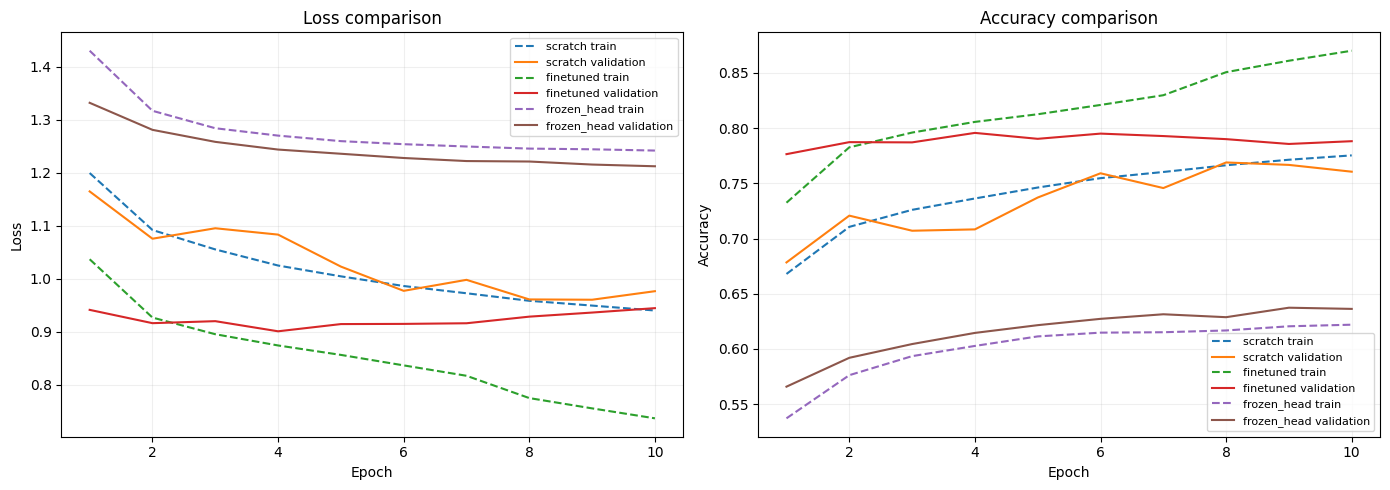

In [6]:
histories = {}
for approach in ('scratch', 'finetuned', 'frozen_head'):
    model = initialize_model(approach)
    print(f'{approach}: {sum(p.numel() for p in model.parameters() if p.requires_grad):,} trainable parameters')
    model, histories[approach] = train_model(model, approach, frozen=approach == 'frozen_head')
    del model
    if device.type == 'cuda':
        torch.cuda.empty_cache()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for approach, history in histories.items():
    epochs = np.arange(1, num_epochs + 1)
    axes[0].plot(epochs, history['train_loss'], '--', label=f'{approach} train')
    axes[0].plot(epochs, history['val_loss'], label=f'{approach} validation')
    axes[1].plot(epochs, history['train_accuracy'], '--', label=f'{approach} train')
    axes[1].plot(epochs, history['val_accuracy'], label=f'{approach} validation')
for axis, title, ylabel in zip(axes, ('Loss comparison', 'Accuracy comparison'), ('Loss', 'Accuracy')):
    axis.set(title=title, xlabel='Epoch', ylabel=ylabel)
    axis.legend(fontsize=8)
    axis.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(artifact_dir / 'training_comparison.png', dpi=160)
plt.show()

### [5 points] Step 6: Evaluate your model on testing set and plot the confusion matrix
In this part, you will learn to evaluate a trained model on testing set, and plot the confusion matrix.
Ideally, a great classification model would have non-zero values only along the diagonal, with zeros in all off-diagonal elements.

**HINTS**
1. Remember to perform the same transforms to your testing set as the validation set.
2. In ```get_predictions```, it is basically the same as you do evaluation.

scratch: test accuracy 76.9500%; balanced accuracy 53.0573%; best validation epoch 8


finetuned: test accuracy 79.8800%; balanced accuracy 57.5500%; best validation epoch 4


frozen_head: test accuracy 64.0900%; balanced accuracy 33.7827%; best validation epoch 9


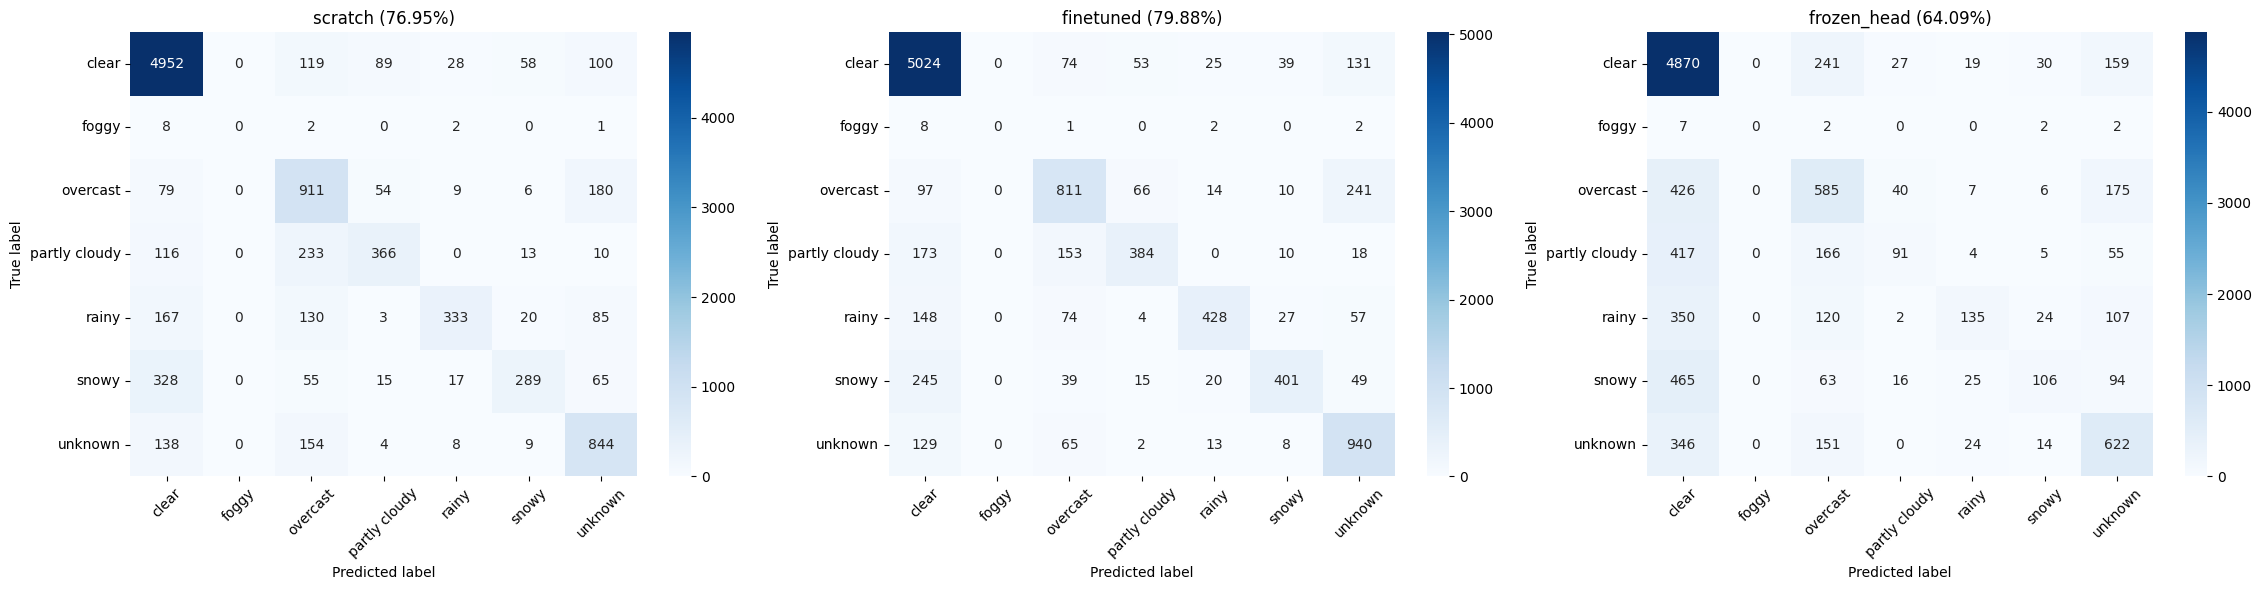

scratch: validation max=76.8911%, test=76.9500%, total training time=3.0 minutes
finetuned: validation max=79.5677%, test=79.8800%, total training time=2.8 minutes
frozen_head: validation max=63.7372%, test=64.0900%, total training time=1.2 minutes
scratch first reached scratch-best validation (76.89%) at epoch 8, after 2.4 minutes.
finetuned first reached scratch-best validation (76.89%) at epoch 1, after 0.3 minutes.
frozen_head did not reach scratch-best validation (76.89%) within 10 epochs.
The frozen-head experiment updates only the final Linear layer; its pretrained backbone and BatchNorm statistics are fixed. Compare its test/balanced accuracy and time above to assess the speed/accuracy tradeoff of not adapting the Tiny ImageNet representation to road weather.


In [7]:
def get_predictions(model, dataloader):
    model.eval()
    predictions, labels = [], []
    with torch.inference_mode():
        for inputs, targets in dataloader:
            with torch.autocast(device_type=device.type, enabled=device.type == 'cuda'):
                outputs = model(inputs.to(device, non_blocking=True))
            predictions.extend(outputs.argmax(1).cpu().numpy())
            labels.extend(targets.numpy())
    return np.array(predictions), np.array(labels)

results = {}
fig, axes = plt.subplots(1, 3, figsize=(23, 6))
for axis, approach in zip(axes, ('scratch', 'finetuned', 'frozen_head')):
    model = yourCNN(num_classes=num_classes).to(device)
    checkpoint = torch.load(artifact_dir / f'{approach}_best_weights.pth', map_location=device, weights_only=True)
    model.load_state_dict(checkpoint['model_state_dict'])
    predictions, true_labels = get_predictions(model, test_loader)
    cm = confusion_matrix(true_labels, predictions, labels=np.arange(num_classes))
    class_accuracy = np.diag(cm) / np.maximum(cm.sum(axis=1), 1)
    accuracy = float(np.mean(predictions == true_labels))
    results[approach] = dict(test_accuracy=accuracy, balanced_accuracy=float(class_accuracy.mean()),
                             best_val_accuracy=checkpoint['val_accuracy'], best_epoch=checkpoint['epoch'],
                             total_training_seconds=sum(histories[approach]['epoch_seconds']),
                             class_accuracy=dict(zip(train_dataset.classes, class_accuracy.tolist())),
                             test_support=dict(zip(train_dataset.classes, cm.sum(axis=1).tolist())))
    np.savez(artifact_dir / f'{approach}_test_predictions.npz', predictions=predictions,
             true_labels=true_labels, confusion_matrix=cm)
    print(f'{approach}: test accuracy {accuracy:.4%}; balanced accuracy {class_accuracy.mean():.4%}; '
          f'best validation epoch {checkpoint["epoch"]}', flush=True)
    for class_name, recall, support in zip(train_dataset.classes, class_accuracy, cm.sum(axis=1)):
        print(f'  {class_name}: recall {recall:.2%} ({support} test images)', flush=True)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axis,
                xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
    axis.set(title=f'{approach} ({accuracy:.2%})', xlabel='Predicted label', ylabel='True label')
    axis.tick_params(axis='x', rotation=45)
    del model
fig.tight_layout()
fig.savefig(artifact_dir / 'confusion_matrices.png', dpi=160)
plt.show()
(artifact_dir / 'results.json').write_text(json.dumps(results, indent=2))

for approach, result in results.items():
    print(f'{approach}: validation max={result["best_val_accuracy"]:.4%}, '
          f'test={result["test_accuracy"]:.4%}, '
          f'total training time={result["total_training_seconds"] / 60:.1f} minutes')
target_accuracy = max(histories['scratch']['val_accuracy'])
for approach in ('scratch', 'finetuned', 'frozen_head'):
    reached = [i for i, value in enumerate(histories[approach]['val_accuracy']) if value >= target_accuracy]
    if reached:
        epoch = reached[0] + 1
        minutes = sum(histories[approach]['epoch_seconds'][:epoch]) / 60
        print(f'{approach} first reached scratch-best validation ({target_accuracy:.2%}) '
              f'at epoch {epoch}, after {minutes:.1f} minutes.')
    else:
        print(f'{approach} did not reach scratch-best validation ({target_accuracy:.2%}) within 10 epochs.')
print('The frozen-head experiment updates only the final Linear layer; its pretrained backbone and '
      'BatchNorm statistics are fixed. Compare its test/balanced accuracy and time above to assess '
      'the speed/accuracy tradeoff of not adapting the Tiny ImageNet representation to road weather.')

### Questions
1. [5 points] What did you observe from the two approaches? Does finetuning really train faster in this case?
2. [5 points] In the above implemetation, the whole model is finetuned to downstream task. Can we just finetune the last fc layer? That is, can we freeze all the weights except the last fc layer during training? Please implement it and analyze the performance.